In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from catboost import CatBoostClassifier

# Утилиты
sys.path.append(os.path.abspath('..'))
from notebook_utils import setup_env, load_data_for_modeling

# 1. Настройка и Данные
PROJECT_ROOT, config = setup_env()
MODELS_DIR = PROJECT_ROOT / config['paths']['models']
target_mode = config['experiment']['target_mode']

In [2]:
df = load_data_for_modeling(config, PROJECT_ROOT, fill_cats=True)
target_col = config['features']['target_col']
cat_cols = config['features']['cat_cols']
num_cols = [c for c in df.columns if c not in cat_cols and c != target_col]

X = df.drop(columns=[target_col])
y = df[target_col]

# Сплит (строго фиксированный)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Test size: {len(X_test)}")

# Словарь для хранения вероятностей
probas = {}

Загрузка данных из: D:\Education\Arcticle\dtp_project\data\processed\dtp_full_dataset.parquet
Режим таргета: binary_severe. Распределение:
target
0    0.6065
1    0.3935
Name: proportion, dtype: float64
Test size: 33490


In [3]:
# ==========================================
# 2. Загрузка Sklearn моделей (LogReg, RandomForest)
# ==========================================
sklearn_models = ['LogisticRegression', 'RandomForest']

print(f"\n=== ЗАГРУЗКА SKLEARN ({sklearn_models}) ===")
for name in sklearn_models:
    try:
        path = MODELS_DIR / f"{name}_{target_mode}.joblib"
        if path.exists():
            model = joblib.load(path)
            # В joblib у нас сохранен Pipeline, он сам сделает OHE и Scaling
            probas[name] = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, probas[name])
            print(f"✓ {name} loaded. AUC: {auc:.4f}")
        else:
            print(f"✗ Файл не найден: {path}")
    except Exception as e:
        print(f"✗ Ошибка загрузки {name}: {e}")

# ==========================================
# 3. Загрузка CatBoost
# ==========================================
print("\n=== ЗАГРУЗКА CATBOOST ===")
try:
    cb_model = CatBoostClassifier()
    cb_path = MODELS_DIR / f"catboost_{target_mode}.cbm"
    cb_model.load_model(str(cb_path))
    probas['CatBoost'] = cb_model.predict_proba(X_test)[:, 1]
    print(f"✓ CatBoost loaded. AUC: {roc_auc_score(y_test, probas['CatBoost']):.4f}")
except Exception as e:
    print(f"✗ Ошибка CatBoost: {e}")

# ==========================================
# 4. Восстановление Neural Network (для Ансамбля)
# ==========================================
# Нейросеть нужна нам только для того, чтобы посчитать Ансамбль
print("\n=== ВОССТАНОВЛЕНИЕ НЕЙРОСЕТИ (Для Ансамбля) ===")
try:
    # 4.1. Препроцессинг для NN (LabelEnc + Scaler)
    X_nn_test = X_test.copy()
    X_nn_train = X_train.copy()
    
    cat_dims = []
    for col in cat_cols:
        le = LabelEncoder()
        # Фитим на объединении, чтобы знать все категории
        full_col = pd.concat([X_nn_train[col], X_nn_test[col]]).astype(str)
        le.fit(full_col)
        X_nn_test[col] = le.transform(X_nn_test[col].astype(str))
        cat_dims.append(len(le.classes_))
        
    scaler = StandardScaler()
    scaler.fit(X_nn_train[num_cols])
    X_test_num_scaled = scaler.transform(X_nn_test[num_cols])
    
    # 4.2. Архитектура
    class TabularModel(nn.Module):
        def __init__(self, cat_dims, num_features, hidden_dims=[512, 256, 128], dropout=0.3):
            super().__init__()
            self.embeddings = nn.ModuleList([
                nn.Embedding(dim, min(50, (dim + 1) // 2)) for dim in cat_dims
            ])
            total_emb_dim = sum([min(50, (dim + 1) // 2) for dim in cat_dims])
            input_dim = total_emb_dim + num_features
            layers = []
            curr_dim = input_dim
            for h_dim in hidden_dims:
                layers.append(nn.BatchNorm1d(curr_dim))
                layers.append(nn.Linear(curr_dim, h_dim))
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout))
                curr_dim = h_dim
            self.mlp = nn.Sequential(*layers)
            self.output = nn.Linear(curr_dim, 1)
        
        def forward(self, x_cat, x_num):
            emb = [e(x_cat[:, i]) for i, e in enumerate(self.embeddings)]
            x = torch.cat(emb + [x_num], dim=1)
            return self.output(self.mlp(x))

    # 4.3. Инференс
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    nn_model = TabularModel(cat_dims, len(num_cols)).to(DEVICE)
    nn_model.load_state_dict(torch.load(MODELS_DIR / "best_neural_net.pth", map_location=DEVICE, weights_only=True))
    nn_model.eval()
    
    x_c = torch.tensor(X_nn_test[cat_cols].values, dtype=torch.long).to(DEVICE)
    x_n = torch.tensor(X_test_num_scaled, dtype=torch.float32).to(DEVICE)
    
    with torch.no_grad():
        nn_probs = torch.sigmoid(nn_model(x_c, x_n)).cpu().numpy().flatten()
        
    print(f"✓ NeuralNet restored. AUC: {roc_auc_score(y_test, nn_probs):.4f}")
    
    # 4.4. Считаем Ансамбль
    if 'CatBoost' in probas:
        probas['Ensemble'] = 0.65 * probas['CatBoost'] + 0.35 * nn_probs
        print(f"✓ Ensemble calculated. AUC: {roc_auc_score(y_test, probas['Ensemble']):.4f}")

except Exception as e:
    print(f"✗ Ошибка NN/Ensemble: {e}")


=== ЗАГРУЗКА SKLEARN (['LogisticRegression', 'RandomForest']) ===


d:\Education\Arcticle\dtp_project\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Education\Arcticle\dtp_project\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Education\Arcticle\dtp_project\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.7.1 when using vers

✓ LogisticRegression loaded. AUC: 0.7249


d:\Education\Arcticle\dtp_project\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Education\Arcticle\dtp_project\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Education\Arcticle\dtp_project\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.7.1 when using vers

✓ RandomForest loaded. AUC: 0.7079

=== ЗАГРУЗКА CATBOOST ===
✓ CatBoost loaded. AUC: 0.7435

=== ВОССТАНОВЛЕНИЕ НЕЙРОСЕТИ (Для Ансамбля) ===
✓ NeuralNet restored. AUC: 0.7369
✓ Ensemble calculated. AUC: 0.7456



График сохранен в: D:\Education\Arcticle\dtp_project\data\processed\final_roc_comparison.png


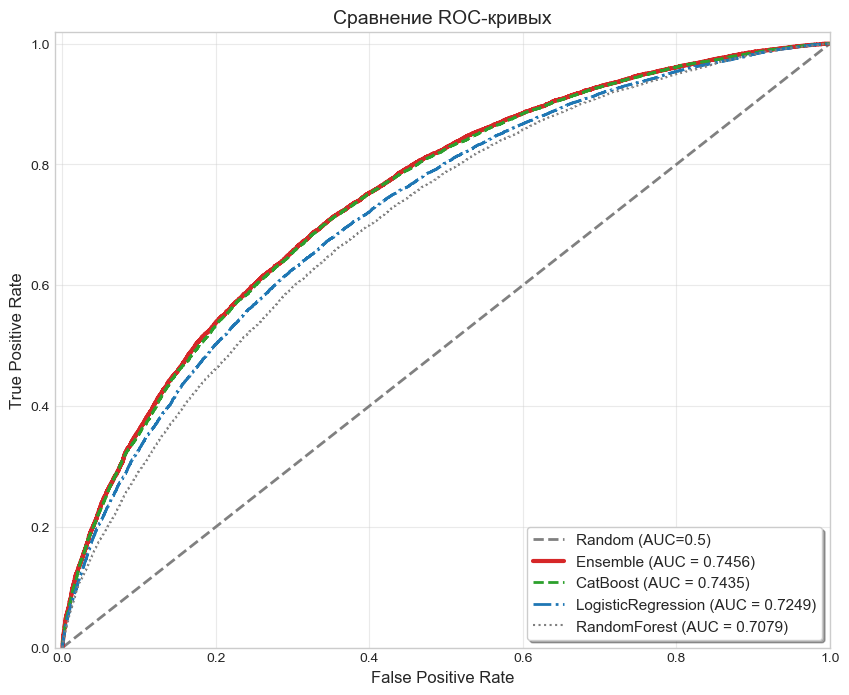

In [5]:
plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# Диагональ
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='gray', label='Random (AUC=0.5)')

# Настройки отображения (Цвет, Толщина, Стиль линии)
model_styles = {
    'Ensemble':           {'color': '#d62728', 'lw': 3.0, 'ls': '-'},   # Красный жирный (Лидер)
    'CatBoost':           {'color': '#2ca02c', 'lw': 2.0, 'ls': '--'},  # Зеленый пунктир
    'LogisticRegression': {'color': '#1f77b4', 'lw': 2.0, 'ls': '-.'}, # Синий штрих-пунктир
    'RandomForest':       {'color': '#7f7f7f', 'lw': 1.5, 'ls': ':'}    # Серый точки (Аутсайдер)
}

# Сортируем легенду по AUC
sorted_keys = sorted(probas.keys(), key=lambda x: roc_auc_score(y_test, probas[x]), reverse=True)

for name in sorted_keys:
    if name not in model_styles: continue # Рисуем только выбранные
    
    y_score = probas[name]
    auc = roc_auc_score(y_test, y_score)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    
    st = model_styles[name]
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', **st)

# Оформление
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Сравнение ROC-кривых', fontsize=14)
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.4)

save_path = PROJECT_ROOT / 'data/processed/final_roc_comparison.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nГрафик сохранен в: {save_path}")
plt.show()